# Mount Drive and set data path

In [1]:
# Colab setup: mount Drive, set project root, add src to path
import sys, os

# Install deps if running on Colab
if 'google.colab' in sys.modules:
    try:
        import torch, torchvision, cv2  # noqa: F401
    except Exception:
        %pip -q install torch torchvision opencv-python tqdm
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/AML-ETH-Project2'
else:
    # Fallback for local runs
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
    %load_ext autoreload
    %autoreload 2

SRC_PATH = os.path.join(PROJECT_ROOT, 'src')
if SRC_PATH not in sys.path:
    sys.path.append(SRC_PATH)

print('Project root:', PROJECT_ROOT)
print('Using src path:', SRC_PATH)

Mounted at /content/drive
Project root: /content/drive/MyDrive/AML-ETH-Project2
Using src path: /content/drive/MyDrive/AML-ETH-Project2/src


In [2]:
# Clear cached modules to force reimport of updated code
import sys
for mod in list(sys.modules.keys()):
    if any(x in mod for x in ['utils', 'dataset', 'models', 'train', 'UNet']):
        del sys.modules[mod]

print("✓ Module cache cleared - fresh import will happen next")

✓ Module cache cleared - fresh import will happen next


# Load Data & imports

In [3]:
import pickle
import gzip
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure
import ipywidgets as widgets
from ipywidgets import IntSlider, FloatSlider, VBox
import os

print('Imports OK')

Imports OK


In [4]:
# Load data from pickled file
from utils.utilities import load_zipped_pickle

pkl_path = PROJECT_ROOT + '/data/raw/train.pkl'
if not os.path.exists(pkl_path):
    raise FileNotFoundError(f'{pkl_path} nicht gefunden im aktuellen Verzeichnis: {os.getcwd()}')
# Get entire dataset
data = load_zipped_pickle(pkl_path)

print('Number of samples:', len(data))

Number of samples: 65


# Train model

In [5]:
# For now, data contains all videos labeled by amateurs. We do a 80/20 train/val split here.
from utils.utilities import make_train_test_split
from dataset import FramesDataset
from models.UNet import UNet, initialize_weights
from torch.utils.data import DataLoader
import torch.nn as nn
import torch

# Split data into train and validation sets. We take validation data only from expert labeled videos.
# test_ratio refers to the fraction of expert labeled videos, NOT total videos.
train_data, val_data = make_train_test_split(data, test_ratio=0.2, random_seed=42)

# set up dataset and dataloader
train_ds = FramesDataset(train_data, augmentation=True)
val_ds = FramesDataset(val_data)
print(f'Training Dataset size: {len(train_ds)}')
print(f'Validation Dataset size: {len(val_ds)}')

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)

# Set up model, optimizer, criterion, device
model = UNet(n_channels=1, n_classes=2)
# Check if model has parameters
params = list(model.parameters())
print(f"Model has {len(params)} parameter tensors")
print(f"Total params: {sum(p.numel() for p in params):,}")
initialize_weights(model)
optim = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device', device)
model = model.to(device)

Training Dataset size: 186
Validation Dataset size: 9
Model has 56 parameter tensors
Total params: 37,651,586
Using device cuda


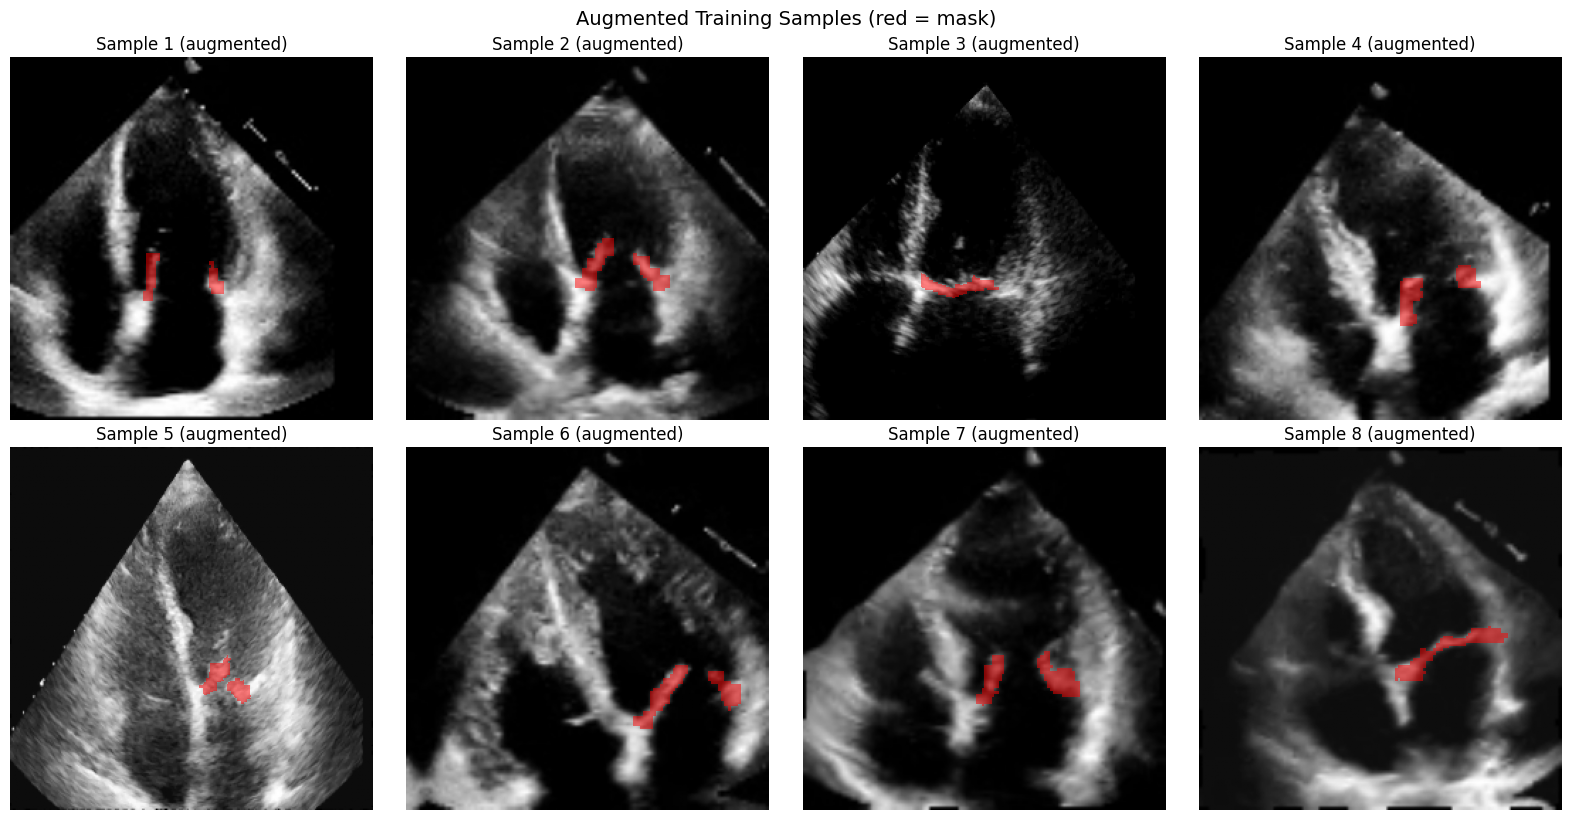

Image range: [0.000, 0.996]
Mask unique values: [0, 1]


In [6]:
# Visualize augmented samples from train_loader
import matplotlib.pyplot as plt

# Get one batch from train_loader
batch = next(iter(train_loader))
imgs, masks = batch

# Show first 8 samples
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(min(8, imgs.shape[0])):
    img = imgs[i, 0].numpy()  # (H, W)
    mask = masks[i].numpy()   # (H, W)

    # Create overlay: image in grayscale, mask in red
    ax = axes[i]
    ax.imshow(img, cmap='gray')

    # Red overlay for mask
    rgba = np.zeros((img.shape[0], img.shape[1], 4))
    rgba[..., 0] = 1.0  # red channel
    rgba[..., 3] = mask * 0.5  # alpha where mask is present
    ax.imshow(rgba, interpolation='nearest')

    ax.set_title(f'Sample {i+1} (augmented)')
    ax.axis('off')

plt.tight_layout()
plt.suptitle('Augmented Training Samples (red = mask)', fontsize=14, y=1.02)
plt.show()

print(f"Image range: [{imgs.min():.3f}, {imgs.max():.3f}]")
print(f"Mask unique values: {torch.unique(masks).tolist()}")

Training next epoch:   0%|          | 0/24 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1: Train Loss=0.2451, Val Loss=0.1031
 ✓ (saved)


Training next epoch:   0%|          | 0/24 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 19: Train Loss=0.0175, Val Loss=0.0180
 (patience 3/5)


Training next epoch:   0%|          | 0/24 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 20: Train Loss=0.0152, Val Loss=0.0178
 ✓ (saved)


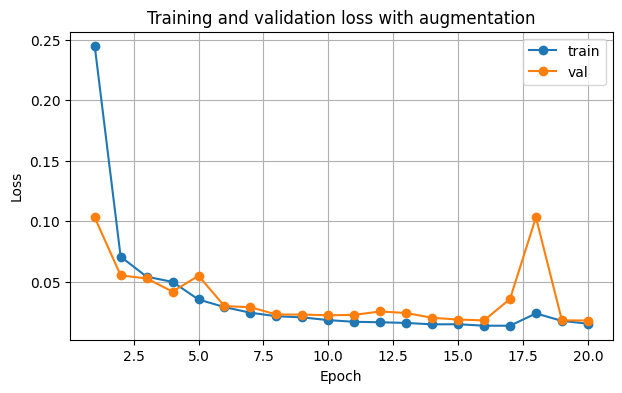

In [ ]:
# If train == True, Train for 20 epochs and plot epoch losses
# otherwise load saved weights
train = True
if train:
  from train import train_model
  epochs = 20
  train_losses = []
  val_losses = []

  loss_history = train_model(model, train_loader, optim, criterion,
                             device=device, epochs=epochs,
                             save_path=PROJECT_ROOT + '/weights/unet_augmented.pth',val_loader=val_loader,
                             patience=5)
  train_losses = loss_history['train']
  val_losses = loss_history['val']
  # Plot losses
  import matplotlib.pyplot as plt
  plt.figure(figsize=(7,4))
  plt.plot(range(1, len(train_losses)+1), train_losses, marker='o', label='train')
  plt.plot(range(1, len(val_losses)+1), val_losses, marker='o', label='val')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Training and validation loss with augmentation')
  plt.legend()
  plt.grid(True)
  plt.show()
else:
  model.load_state_dict(torch.load(PROJECT_ROOT + '/weights/unet_augmented.pth'))

# Model evaluation

We have to be carefull how to scale our data when making predictions. Our model is trained to make predictions for 256 x 256 images. So to get a prediction for arbitrary images, we have to 1. rescale the image 2. get prediction mask 3. do the inverse rescaling of the mask to get prediction for the original image.

We first compute median Jaccard Index on val_data an then visualize the predicted masks on one of the videos in val_data

In [8]:
# Compute median Jaccard Index (IoU) on val_loader (frame-level)
import numpy as np

model.eval()
iou_scores = []
with torch.no_grad():
    for imgs, masks in val_loader:
        imgs = imgs.to(device)
        masks = masks.to(device)
        logits = model(imgs)
        preds = torch.argmax(torch.softmax(logits, dim=1), dim=1)  # (B,H,W)
        # per-sample IoU
        for p, t in zip(preds, masks):
            p_bin = p.bool()
            t_bin = t.bool()
            inter = (p_bin & t_bin).sum().item()
            union = (p_bin | t_bin).sum().item()
            if union == 0:
                iou = 1.0  # both empty
            else:
                iou = inter / union
            iou_scores.append(iou)

median_iou = float(np.median(iou_scores)) if iou_scores else float('nan')
print(f"Median IoU on val_loader: {median_iou:.4f} (n={len(iou_scores)} frames)")


Median IoU on val_loader: 0.3995 (n=9 frames)


Visualize masks for all frames of one sample video from validation data.

In [11]:
from utils.utilities import get_mask_from_image
# Inference with slider: predict masks for all frames of first validation video and browse them
sample = val_data[1]
video = sample['video']  # shape assumed (H, W, T)

H, W, T = video.shape
num_frames = T // 2

# ensure model on device and eval
model = model.to(device)
model.eval()

# run inference for all frames (single-channel input assumed)
masks_pred = []

with torch.no_grad():
    for i in range(0, num_frames):
        frame = video[..., i].astype('float32') / 255.0  # (H,W)
        mask = get_mask_from_image(frame, model, 256, 256)  # (H,W) binary
        masks_pred.append(mask)

masks_pred = np.stack(masks_pred, axis=0)  # (T,H,W)
print('Predicted masks shape (T,H,W):', masks_pred.shape)

# slider to browse frames with overlay
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import IntSlider

frame_slider = IntSlider(min=0, max=num_frames-1, value=0, description='frame')

def show_pred_frame(t):
    plt.figure(figsize=(5,5))
    plt.imshow(video[..., t], cmap='gray')
    rgba = np.zeros((H, W, 4), dtype=np.float32)
    rgba[..., 0] = 1.0
    rgba[..., 3] = masks_pred[t].astype(float) * 0.5
    plt.imshow(rgba, interpolation='nearest')
    plt.title(f"Frame {t} overlay")
    plt.axis('off')
    plt.show()

widgets.interact(show_pred_frame, t=frame_slider)

Predicted masks shape (T,H,W): (58, 579, 844)


interactive(children=(IntSlider(value=0, description='frame', max=57), Output()), _dom_classes=('widget-intera…

<function __main__.show_pred_frame(t)>

Visualize predicted mask, vs. label mask on validation data.

In [10]:
# Visualize val_loader predictions vs labels with a slider (all frames)
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import IntSlider

model.eval()
all_imgs = []
all_gts = []
all_preds = []
with torch.no_grad():
    for imgs, masks in val_loader:
        imgs = imgs.to(device)
        masks = masks.to(device)
        logits = model(imgs)
        preds = torch.argmax(torch.softmax(logits, dim=1), dim=1)  # (B,H,W)
        # move to cpu numpy
        all_imgs.append(imgs.cpu().numpy())        # (B,1,H,W)
        all_gts.append(masks.cpu().numpy())        # (B,H,W)
        all_preds.append(preds.cpu().numpy())      # (B,H,W)

# stack along batch dimension
imgs_np = np.concatenate(all_imgs, axis=0)   # (N,1,H,W)
gts_np = np.concatenate(all_gts, axis=0)     # (N,H,W)
preds_np = np.concatenate(all_preds, axis=0) # (N,H,W)
N, _, H, W = imgs_np.shape
print(f'Collected {N} frames from val_loader for visualization: shape (N,H,W)=({N},{H},{W})')

frame_slider = IntSlider(min=0, max=N-1, value=0, description='frame')

def show_overlay(i):
    img = imgs_np[i, 0]  # assume single channel
    gt = gts_np[i]
    pr = preds_np[i]
    plt.figure(figsize=(5,5))
    plt.imshow(img, cmap='gray')
    rgba = np.zeros((H, W, 4), dtype=np.float32)
    # green = label, red = prediction
    rgba[..., 1] = gt.astype(float)       # green channel
    rgba[..., 0] = pr.astype(float)       # red channel
    rgba[..., 3] = 0.45 * ((gt + pr) > 0).astype(float)  # alpha where either mask is present
    plt.imshow(rgba, interpolation='nearest')
    plt.title(f'Frame {i}: green=label, red=pred')
    plt.axis('off')
    plt.show()

widgets.interact(show_overlay, i=frame_slider);

Collected 9 frames from val_loader for visualization: shape (N,H,W)=(9,256,256)


interactive(children=(IntSlider(value=0, description='frame', max=8), Output()), _dom_classes=('widget-interac…